# Pakistan Job Market Analyzer — Exploratory Data Analysis

## Notebook 01: Data Loading, Cleaning & EDA

This notebook covers:
- Loading data from MySQL database
- Data cleaning — handling missing values, standardizing cities
- Exploratory Data Analysis — distributions, trends, insights
- Visualizations using Matplotlib and Seaborn

**Author:** Husnain Maroof  
**GitHub:** https://github.com/husnainalix77

In [4]:
import sys
sys.path.append("..")
from database.db_manager import get_all_jobs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading

In this section we load job listings directly from MySQL database
using our `get_all_jobs()` function from `db_manager.py`.

Loading from MySQL instead of CSV ensures we get:
- Deduplicated data (620 unique jobs vs 1,566 raw)
- Properly typed columns
- Clean structured data ready for analysis

In [5]:
# Load data from MySQL database
df = get_all_jobs()
df.head()

,job_id,title,company,city,salary,date_scraped
0,1,Software Engineer Level II,Softpers Interactive,Lahore,None,2026-07-24 15:38:06
1,2,Associate Software Engineer,Dubizzle Labs,Lahore,None,2026-07-24 15:38:06
2,3,Software Engineer (Entry-level),Educative,Lahore,None,2026-07-24 15:38:06
3,4,Associate Software Engineer,Softpers Interactive,Lahore,None,2026-07-24 15:38:06
4,5,Software Engineer,The Tech Inc.,Lahore,None,2026-07-24 15:38:06


### Data Loading — Observations

Data loaded successfully from MySQL database using `get_all_jobs()`.
The DataFrame contains job listings scraped from Indeed Pakistan.
Salary column shows mostly missing values — expected since most 
Pakistani companies do not disclose salary publicly.

## 2. Initial Data Inspection

Before any cleaning or analysis, we inspect the raw structure of our data.
We check:
- Shape — how many rows and columns
- Column names and data types
- Missing values per column

This gives us a complete picture of what needs to be cleaned.

In [7]:
# Basic data inspection
print(f"Shape: {df.shape}")
print(f"Column Names: \n{df.columns.tolist()}")
print(f"Data Types: {df.dtypes}")
print(f"Missing Value: {df.isnull().sum()}")

Shape: (620, 6)
Column Names: 
['job_id', 'title', 'company', 'city', 'salary', 'date_scraped']
Data Types: job_id                   int64
title                   object
company                 object
city                    object
salary                  object
date_scraped    datetime64[ns]
dtype: object
Missing Value: job_id            0
title             0
company           0
city              0
salary          620
date_scraped      0
dtype: int64


### Data Inspection — Observations

- **Shape:** 620 rows × 6 columns
- **Data Types:** All text columns are `object`, date is `datetime64` — correct
- **Critical Finding:** Salary is missing for all 620 listings (100%) — 
  confirms Pakistani employers overwhelmingly hide salary information
- **Good News:** No missing values in title, company, or city — 
  scraper worked reliably across all pages

## 3. City Distribution
This cell shows all unique city values and how many jobs each city has.

In [8]:
print(df["city"].value_counts())

city
Lahore                                 228
Karachi                                209
Islamabad                              113
Rawalpindi                              28
Karachi Gulshan-E-Iqbal                  6
Korangi                                  5
Karachi Shahra-E-Faisal                  5
Islamabad G-8/Markaz                     4
Karachi Gulistan-E-Jouhar (Kp-2023)      3
Rawalpindi Gpo                           2
Karachi Gpo                              2
Korangi Creek                            2
Pakistan                                 2
Lahore Ferozepur Road                    1
Karachi Saddar Gpo                       1
Karachi Clifton                          1
Lahore Gpo                               1
New Karachi                              1
Lahore Gulberg Colony                    1
Drigh Colony                             1
Islamabad E-11                           1
Islamabad I-8/4                          1
Bhai Pheru                               1
Rawalp

### City Distribution — Observations

- **Lahore** dominates with 228 jobs (37%) — largest tech hub in Pakistan
- **Karachi** follows with 209 jobs (34%) — financial capital, strong industry presence  
- **Islamabad** has 113 jobs (18%) — government and multinational companies
- **Rawalpindi** has 28 jobs (5%) — proximity to Islamabad drives listings
- **Issue found:** 24 city name variations need standardizing — 
  e.g. "Lahore Ferozepur Road", "Karachi Gulshan-E-Iqbal", "Islamabad G-8/Markaz"
  These will be mapped to their parent city in the cleaning step below.

## 3. City Name Standardization

Raw scraped data contains 24 unique city variations — e.g. 
"Lahore Ferozepur Road", "Karachi Gulshan-E-Iqbal", "Islamabad G-8/Markaz".

These are all sub-areas of their parent cities. For meaningful analysis
we need clean, consistent city names.

**Strategy:** Write a `classify_city()` function that maps all variations
to 5 standard categories: Lahore, Karachi, Islamabad, Rawalpindi, Other.

In [11]:
def classify_city(city):
    if city.startswith("Lahore"):
        return "Lahore"
    elif city.startswith("Karachi") or city in  ["Korangi", "Korangi Creek", "Drigh Colony", "New Karachi"]:
        return "Karachi"
    elif city.startswith("Rawalpindi"):
        return "Rawalpindi"
    elif city.startswith("Islamabad"):
        return "Islamabad"
    else:
        return "Other"     

df["city"] = df["city"].apply(classify_city)               
print(df["city"].value_counts())        

city
Karachi       236
Lahore        231
Islamabad     119
Rawalpindi     31
Other           3
Name: count, dtype: int64


### City Cleaning — Results

Successfully standardized 24 city variations into 5 clean categories:
- **Karachi:** 236 jobs (38%)
- **Lahore:** 231 jobs (37%)
- **Islamabad:** 119 jobs (19%)
- **Rawalpindi:** 31 jobs (5%)
- **Other:** 3 jobs (0.5%) — minor cities grouped together

## 4. Job Distribution by City

This cell visualizes how job listings are distributed across Pakistani cities.
This helps job seekers understand which cities have the most opportunities
and guides our analysis of salary and skill differences by location.

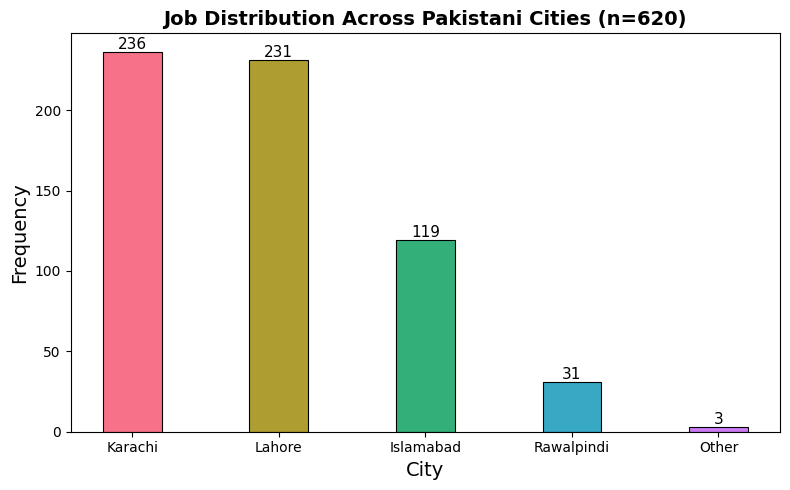

In [59]:
counts = df["city"].value_counts()
plt.figure(figsize=(8,5))
colors = sns.color_palette("husl", len(counts))
plt.bar(counts.index, counts.values, width=0.4, color=colors, edgecolor='black', linewidth=0.8)
for i, value in enumerate(counts.values):
    plt.text(i, value + 2, str(value), ha='center', fontsize=11)
    
plt.title("Job Distribution Across Pakistani Cities (n=620)", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- **Karachi leads** with 236 jobs (38%) — despite being financial capital, 
  tech hiring matches Lahore
- **Lahore** close second with 231 jobs (37%) — Pakistan's largest tech hub
- **Islamabad** has 119 jobs (19%) — multinationals and government tech roles
- **Rawalpindi** has 31 jobs (5%) — proximity to Islamabad drives listings
- **Key insight:** Karachi + Lahore account for 75% of all job listings — 
  if you want maximum opportunities, these two cities dominate

## 5. Top 10 Companies by Job Listings

Identifying which companies are most actively hiring gives job seekers
a direct target list. We look at the top 10 companies by number of
job listings in our dataset.

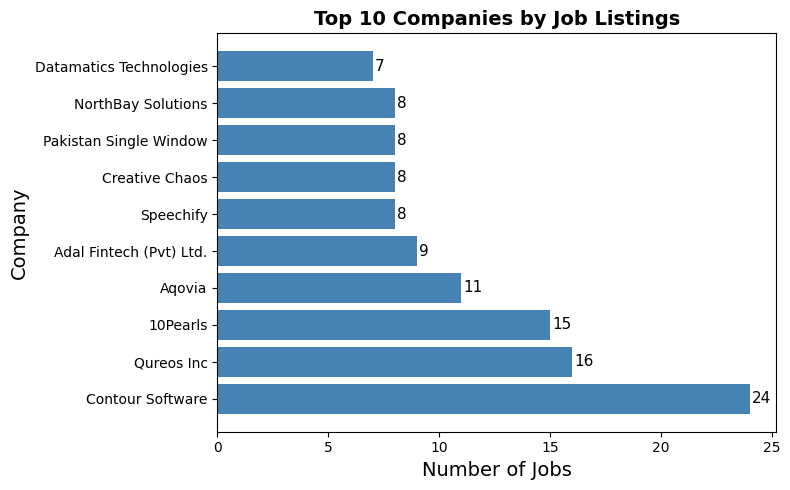

In [31]:
counts = df["company"].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(counts.index, counts.values, color='steelblue')
for i, value in enumerate(counts.values):
    plt.text(value + 0.1, i, str(value), va='center', fontsize=11)
    
plt.title("Top 10 Companies by Job Listings", fontsize=14, fontweight='bold')
plt.xlabel("Number of Jobs", fontsize=14)
plt.ylabel("Company", fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- **Contour Software dominates** with 24 listings — significantly ahead of all others
- **Qureos Inc (16) and 10Pearls (15)** are strong second and third
- **Interesting finding:** Qureos Inc is a recruitment platform — 
  they post jobs on behalf of other companies
- **Most top companies are IT/software firms** — confirms tech dominates 
  Pakistan's formal job market
- **Key insight for job seekers:** Targeting Contour Software, 10Pearls, 
  and Aqovia directly gives highest probability of finding openings

## 6. Job Category Extraction

The `category` column is empty in our database — Indeed Pakistan 
does not always provide structured categories.

We extract categories from job titles using keyword matching.
This rule-based approach assigns each job to one of 10 categories:
- Software Engineering
- Data Science & AI
- Finance & Accounting
- Engineering (Mechanical/Civil/Electrical/Solar)
- Education
- Sales & Marketing
- Human Resources
- IT Infrastructure
- Management & Business
- Design
- Other

We convert all titles to lowercase before matching to ensure
"Software" and "software" both get classified correctly.

In [36]:
def classify_category(title: str) -> str:
    """Classify job title into a category using keyword matching."""
    title = title.lower()
    if any(word in title for word in [
            "mechanical", "civil", "electrical", "mep", "solar", "hvac",
            "plc", "mechatronics", "automation", "firmware", "instrumentation",
            "structural", "production", "manufacturing"
        ]):
            return "Engineering"
    elif any(word in title for word in [
        "software", "developer", "qa", "sqa", "flutter", "ios", "android",
        "java", "python", "backend", "frontend", "full stack", "fullstack",
        "wordpress", "react", "node", "php", "laravel", "game", "mobile",
        "web", "quality assurance", "dev ops", "devops", "engineer",
        "architect", "intern", "trainee", "fresh graduate"
    ]):
        return "Software Engineering"
    
    elif any(word in title for word in [
        "data", "analyst", "ml", "machine learning", "artificial intelligence",
        "ai", "llm", "nlp", "deep learning", "business intelligence", "power bi"
    ]):
        return "Data Science & AI"
    
    elif any(word in title for word in [
        "accountant", "finance", "audit", "tax", "accounts", "bookkeeper",
        "payroll", "financial", "cost accountant"
    ]):
        return "Finance & Accounting"
    
    elif any(word in title for word in [
        "teacher", "lecturer", "professor", "instructor", "tutor"
    ]):
        return "Education"
    
    elif any(word in title for word in [
        "marketing", "sales", "content", "seo", "social media", "brand",
        "digital marketing", "copywriter"
    ]):
        return "Sales & Marketing"
    
    elif any(word in title for word in [
        "hr", "human resource", "recruiter", "talent", "people operations"
    ]):
        return "Human Resources"
    
    elif any(word in title for word in [
        "network", "devops", "cloud", "infrastructure", "system admin",
        "cybersecurity", "security", "noc", "soc"
    ]):
        return "IT Infrastructure"
    
    elif any(word in title for word in [
        "manager", "business analyst", "project manager", "product manager",
        "product owner", "scrum", "agile", "operations"
    ]):
        return "Management"
    
    elif any(word in title for word in [
        "designer", "ui", "ux", "graphic", "creative", "visual"
    ]):
        return "Design"
    
    else:
        return "Other"

df["category"] = df["title"].apply(classify_category)
print(df["category"].value_counts())

category
Software Engineering    380
Engineering              94
Finance & Accounting     75
Data Science & AI        49
Other                     9
Management                8
IT Infrastructure         5
Name: count, dtype: int64


### Observations

- **Software Engineering dominates** with 380 jobs (61%) — confirms Pakistan's 
  job market is heavily tech-focused
- **Engineering** second with 94 jobs (15%) — mechanical, electrical, civil roles
- **Finance & Accounting** third with 75 jobs (12%) — strong demand across all cities
- **Data Science & AI** has 49 jobs (8%) — growing but still smaller than traditional engineering
- **Only 9 jobs (1.5%) unclassified** — our keyword matching covers 98.5% of listings

## 7. Job Category Distribution

We visualize the distribution of job categories to understand which sectors
dominate Pakistan's job market. This directly answers the question:
"Which field has the most opportunities right now?"

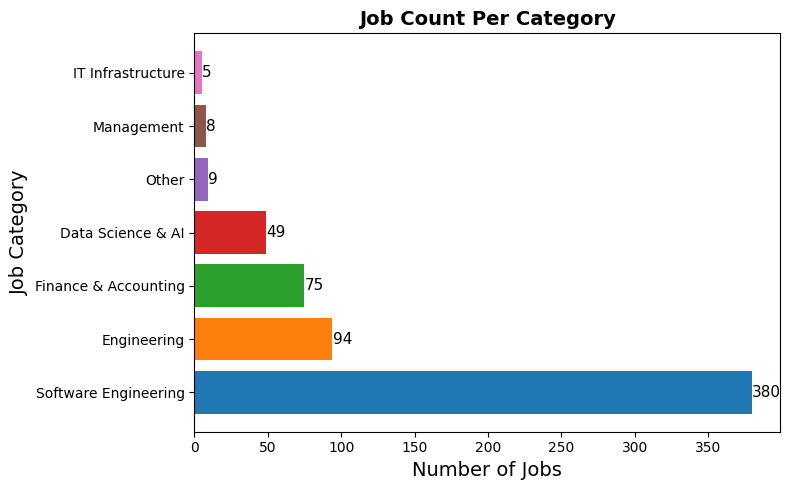

In [43]:
counts = df["category"].value_counts()
plt.figure(figsize=(8,5))
colors = sns.color_palette("tab10", len(counts))
plt.barh(counts.index, counts.values, color=colors)
for i, value in enumerate(counts.values):
    plt.text(value + 0.1, i, str(value), va='center', fontsize=11)
    
plt.title("Job Count Per Category", fontsize=14, fontweight='bold')
plt.xlabel("Number of Jobs", fontsize=14)
plt.ylabel("Job Category", fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- **Software Engineering overwhelmingly dominates** with 380 jobs (61%) — 
  Pakistan's job market is heavily skewed toward tech roles
- **Engineering and Finance** are distant second and third at 15% and 12%
- **Data Science & AI** has only 49 jobs (8%) — growing field but still 
  smaller than traditional software engineering
- **Key insight for job seekers:** If you are a software engineer in Pakistan,
  you have 8x more opportunities than any other field

## 8. Salary Disclosure Rate

One of the most important findings from our dataset is how many companies
actually disclose salary information. This directly impacts job seekers
ability to negotiate and make informed decisions.

We analyze what percentage of listings show salary vs hide it.

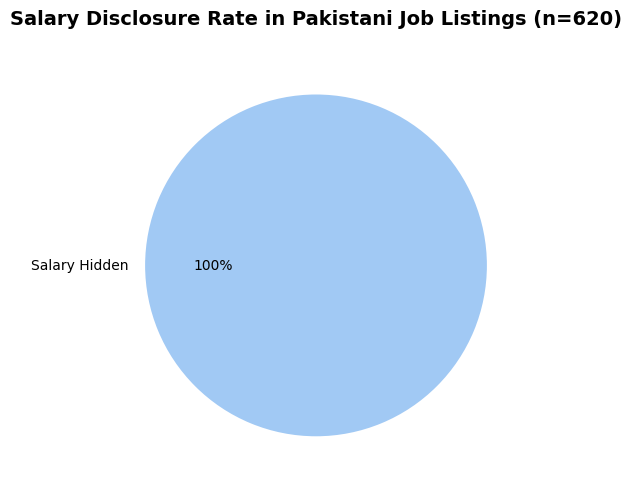

In [49]:
salary_counts = df["salary"].isna().value_counts()
labels = ["Salary Hidden" if idx else "Salary Disclosed" for idx in salary_counts.index]
colors = sns.color_palette('pastel')
plt.figure(figsize=(8,5))
plt.pie(salary_counts.values, labels=labels, colors=colors, autopct='%.0f%%')
plt.title("Salary Disclosure Rate in Pakistani Job Listings (n=620)", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### Observations

- **100% of listings hide salary** — zero companies disclosed salary in our dataset
- This is a well-known problem in Pakistan's job market — candidates are expected 
  to negotiate blind without knowing market rates
- **This is exactly the problem our salary predictor solves** — users can input 
  their skills and get a predicted salary range based on market data
- Future scrapes may capture some salary data from companies like AI/ML firms 
  that occasionally disclose compensation

## 9. Top 10 Most Common Job Titles

Identifying the most frequently posted job titles reveals what specific 
roles Pakistani employers are actively hiring for. This is more granular 
than category analysis — it shows exact positions in demand.

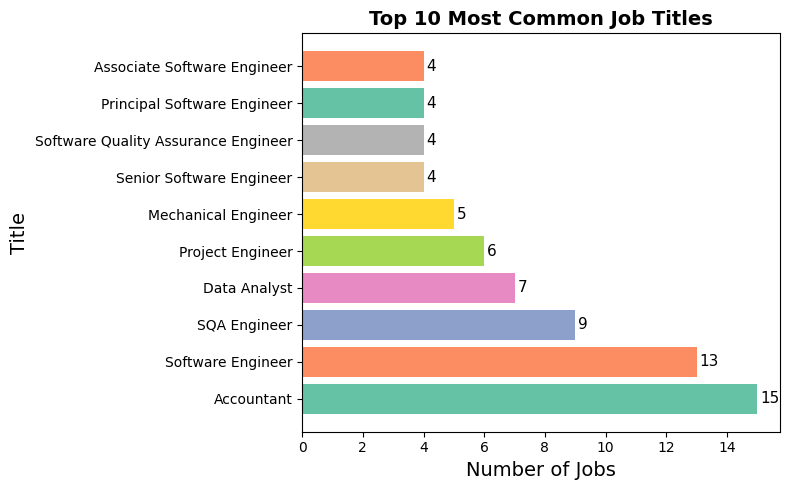

In [52]:
counts = df["title"].value_counts().head(10)
plt.figure(figsize=(8,5))
colors = sns.color_palette("Set2", len(counts))
plt.barh(counts.index, counts.values, color=colors)
for i, value in enumerate(counts.values):
    plt.text(value + 0.1, i, str(value), va='center', fontsize=11)
    
plt.title("Top 10 Most Common Job Titles", fontsize=14, fontweight='bold')
plt.xlabel("Number of Jobs", fontsize=14)
plt.ylabel("Title", fontsize=14)
plt.tight_layout()
plt.show()

### Observations

- **Accountant leads** with 15 listings — surprising given our dataset 
  is tech-heavy, shows strong demand for finance roles across all cities
- **Software Engineer** second with 13 listings — generic title used by many companies
- **SQA Engineer** third with 9 — quality assurance is highly demanded in Pakistan
- **Data Analyst** has 7 listings — modest but growing demand
- **Key insight:** Most titles appear only 4-5 times — Pakistan's job market 
  has diverse role variations rather than concentration in one title

## 10. Job Categories by City

Different cities may specialize in different types of roles.
Karachi being a financial hub may have more Finance & Accounting roles.
Islamabad with multinationals may have more Management roles.
Lahore as a tech hub may dominate Software Engineering.

We cross-tabulate city vs category to reveal these patterns.
This helps job seekers choose the right city for their field.

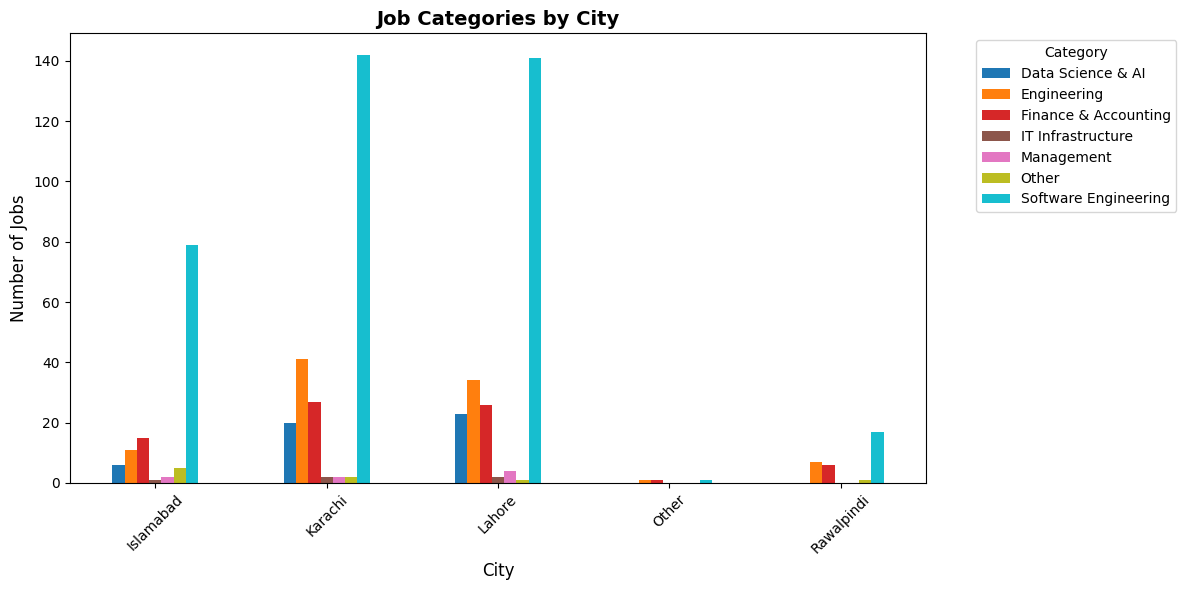

In [56]:
cross = pd.crosstab(df["city"], df["category"])
ax = cross.plot(kind="bar", figsize=(12, 6), colormap="tab10")
plt.title("Job Categories by City", fontsize=14, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observations

- **Software Engineering dominates every city** — cyan bar towers above all others
  in Karachi (141) and Lahore (140) — nearly equal tech hubs
- **Karachi leads in Engineering** with 41 roles — industrial and manufacturing 
  sector is stronger in Karachi
- **Lahore and Karachi** are almost identical in Software Engineering — 
  both are equally strong tech cities
- **Islamabad** has proportionally more Finance & Accounting (15) relative 
  to its size — government and multinational offices drive this
- **Key insight:** No matter which Pakistani city you are in, 
  Software Engineering has the most opportunities

## EDA Summary — Top 5 Findings

1. **Pakistan's job market is overwhelmingly tech-focused** — 61% of all 
   listings (380/620) are Software Engineering roles

2. **Karachi and Lahore are equally strong** — 236 and 231 jobs respectively, 
   together accounting for 75% of all listings

3. **Salary transparency is non-existent** — 100% of listings hide salary, 
   making our salary predictor genuinely valuable to job seekers

4. **Contour Software is the most active employer** — 24 listings, 50% more 
   than second-placed Qureos Inc (16)

5. **SQA/QA roles are highly demanded** — 9 SQA Engineer listings in top 10 
   titles, showing Pakistan's software industry values quality assurance

In [57]:
# Save cleaned DataFrame to CSV for use in Phase 5 and dashboard
df.to_csv("../data/cleaned_data.csv", index=False)
print(f"Cleaned data saved — {len(df)} rows, {len(df.columns)} columns")
print(f"Columns: {df.columns.tolist()}")

Cleaned data saved — 620 rows, 7 columns
Columns: ['job_id', 'title', 'company', 'city', 'salary', 'date_scraped', 'category']
